# Demographic Transition: Age Distributions and Fertility Rates

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

from src.demographics import bgp_growth_rate, simulate_cohort_sizes, compute_age_distribution

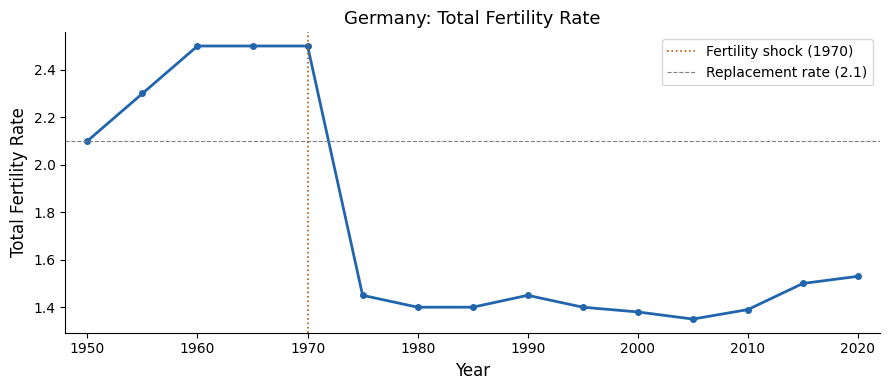

Saved figures/tfr_germany.png


In [2]:
# Historical TFR for Germany (approximate)
tfr_years = [1950, 1955, 1960, 1965, 1970, 1975, 1980, 1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020]
tfr_values = [2.10, 2.30, 2.50, 2.50, 2.50, 1.45, 1.40, 1.40, 1.45, 1.40, 1.38, 1.35, 1.39, 1.50, 1.53]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(tfr_years, tfr_values, color='#2166ac', lw=2, marker='o', ms=4)
ax.axvline(1970, color='#b35806', lw=1.2, ls=':', label='Fertility shock (1970)')
ax.axhline(2.1, color='gray', lw=0.8, ls='--', label='Replacement rate (2.1)')
ax.set_xlim(1948, 2022)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total Fertility Rate', fontsize=12)
ax.set_title('Germany: Total Fertility Rate', fontsize=13)
ax.legend(fontsize=10)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
fig.savefig('../figures/tfr_germany.png', dpi=150)
plt.show()
print("Saved figures/tfr_germany.png")

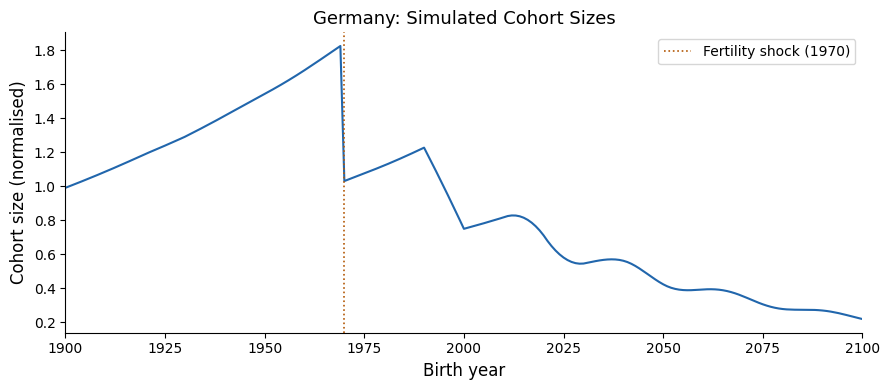

Saved figures/cohort_sizes_germany.png


In [3]:
J, F_low, F_high = 80, 20, 30
b_high = 2.5 / 20   # two-sex
b_low  = 1.4 / 20

dem = simulate_cohort_sizes(b_high, b_low, shock_year=1970,
                             base_year=1900, end_year=2100,
                             J=J, F_low=F_low, F_high=F_high)
years        = dem['years']
cohort_sizes = dem['cohort_sizes']

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(years, cohort_sizes, color='#2166ac', lw=1.5)
ax.axvline(1970, color='#b35806', lw=1.2, ls=':', label='Fertility shock (1970)')
ax.set_xlim(1900, 2100)
ax.set_xlabel('Birth year', fontsize=12)
ax.set_ylabel('Cohort size (normalised)', fontsize=12)
ax.set_title('Germany: Simulated Cohort Sizes', fontsize=13)
ax.legend(fontsize=10)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
fig.savefig('../figures/cohort_sizes_germany.png', dpi=150)
plt.show()
print("Saved figures/cohort_sizes_germany.png")

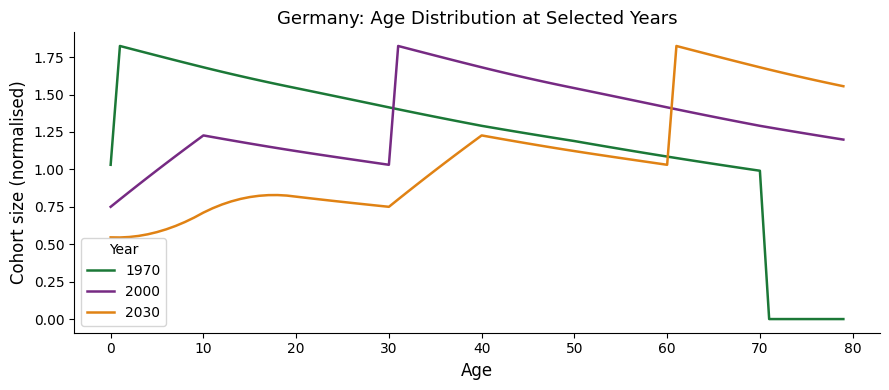

Saved figures/age_distribution_germany.png


In [4]:
eval_years = [1970, 2000, 2030]
colors = ['#1b7837', '#762a83', '#e08214']

fig, ax = plt.subplots(figsize=(9, 4))
for yr, color in zip(eval_years, colors):
    dist = compute_age_distribution(cohort_sizes, years, eval_year=yr, J=J)
    ax.plot(range(J), dist, color=color, lw=1.8, label=str(yr))

ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Cohort size (normalised)', fontsize=12)
ax.set_title('Germany: Age Distribution at Selected Years', fontsize=13)
ax.legend(title='Year', fontsize=10)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
fig.savefig('../figures/age_distribution_germany.png', dpi=150)
plt.show()
print("Saved figures/age_distribution_germany.png")

## Mechanism

When the fertility rate collapses in 1970, each subsequent birth cohort is smaller than the one before. As the large pre-shock cohorts age into their peak saving years (ages 40–60), aggregate asset demand rises sharply while the shrinking working-age population provides less capital demand — driving interest rates down. The age distribution shift from a broad pyramid (1970) to a top-heavy structure (2030) is the direct demographic force behind the secular decline in real interest rates.